In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\GFD LAB\Documents\Anwesha Chakraborty\output\Final_Dataset_ERA5.csv")

In [3]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Datetime,21689,2025-03-30 08:40:01.770482,2024-01-01 00:00:00,2024-08-14 14:00:00,2025-03-29 00:00:00,2025-11-14 13:00:00,2026-06-29 23:00:00,NaN
PM2.5_Mean,21689.0,97.701972,5.011,40.382414,69.217742,129.576,826.679091,82.131117
Visibility,21689.0,3240.332412,0.0,2204.80128,3492.27648,4007.26656,9994.02624,1430.554719
Temperature,21689.0,24.978105,5.025818,18.58609,26.877777,31.029663,46.171387,8.47672
RH,21689.0,65.889007,10.570574,47.909508,69.986145,84.722115,100.00102,21.840721
WindSpeed,21689.0,2.279355,0.010084,1.498599,2.116715,2.849766,8.333353,1.157075
BLH,21689.0,509.172725,11.589531,64.548454,190.20053,690.53314,5054.6445,712.686983


In [7]:
monthly = df.groupby(df["Datetime"].dt.to_period("M"))[["PM2.5_Mean", "Visibility", "Temperature", "RH", "WindSpeed", "BLH"]].mean()
monthly.index = monthly.index.to_timestamp()

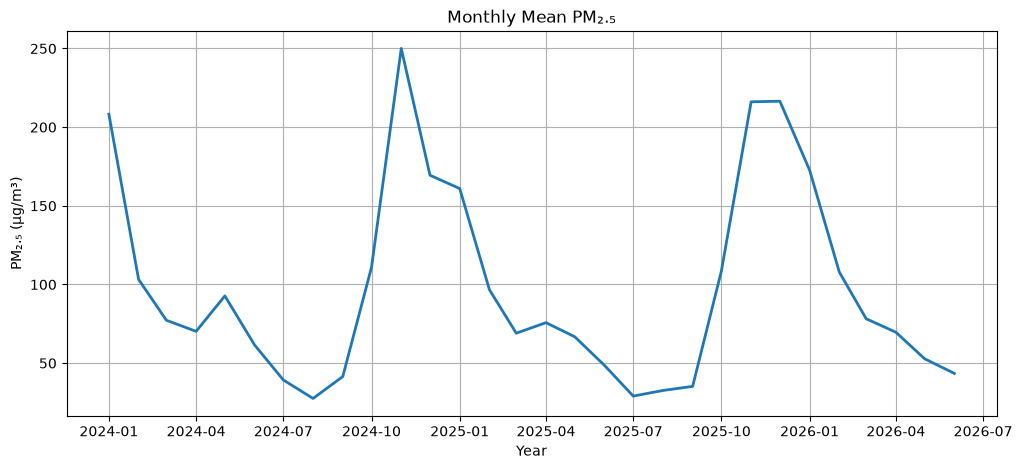

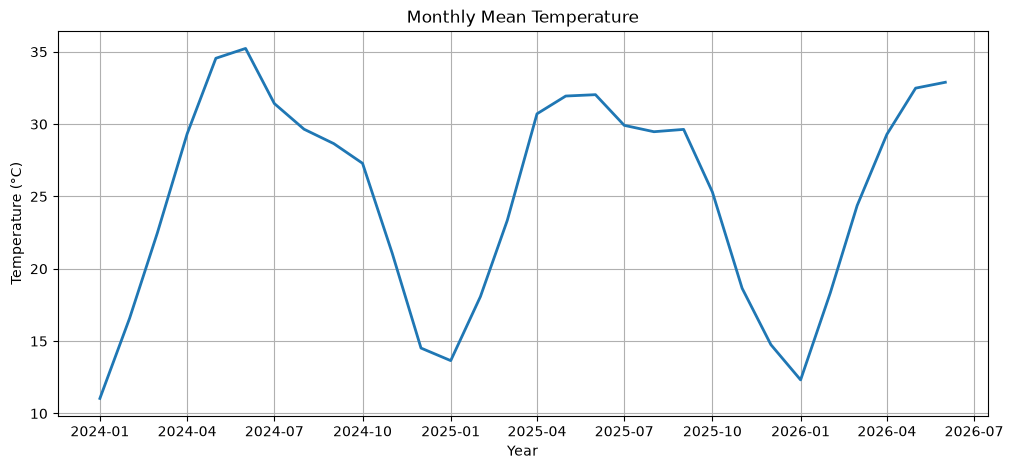

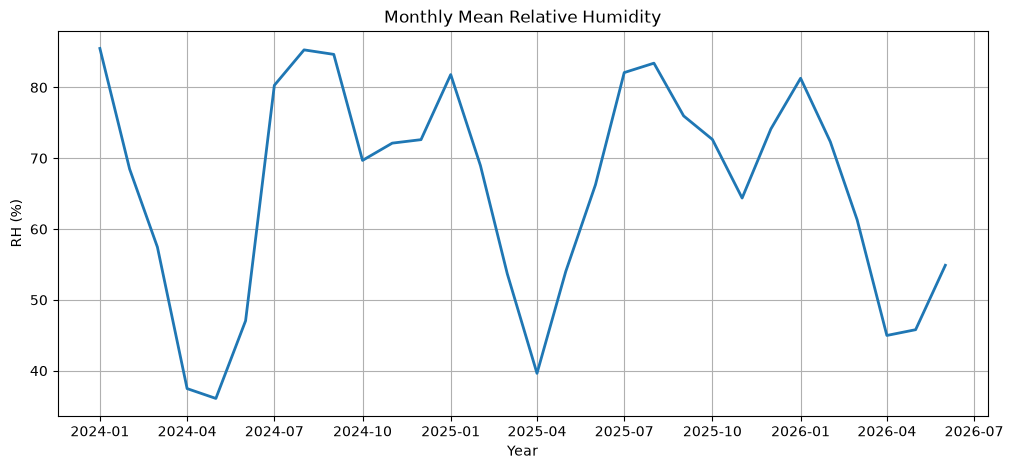

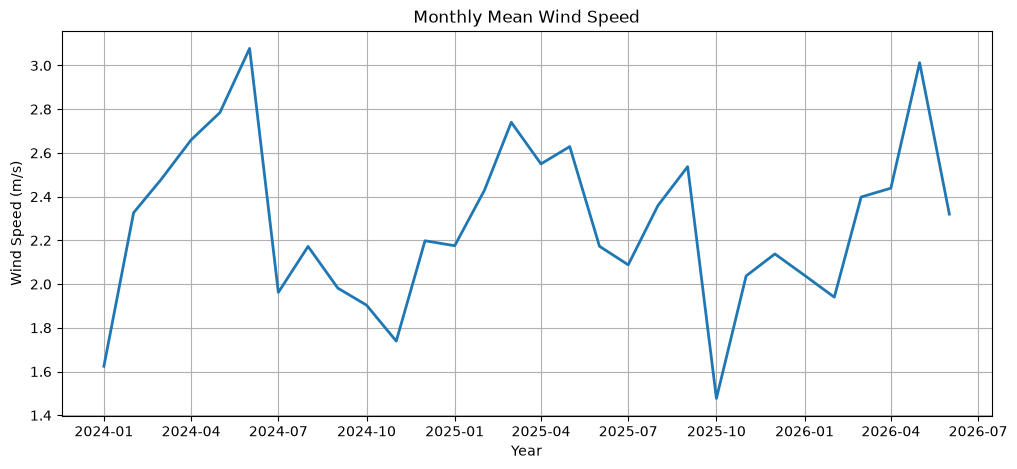

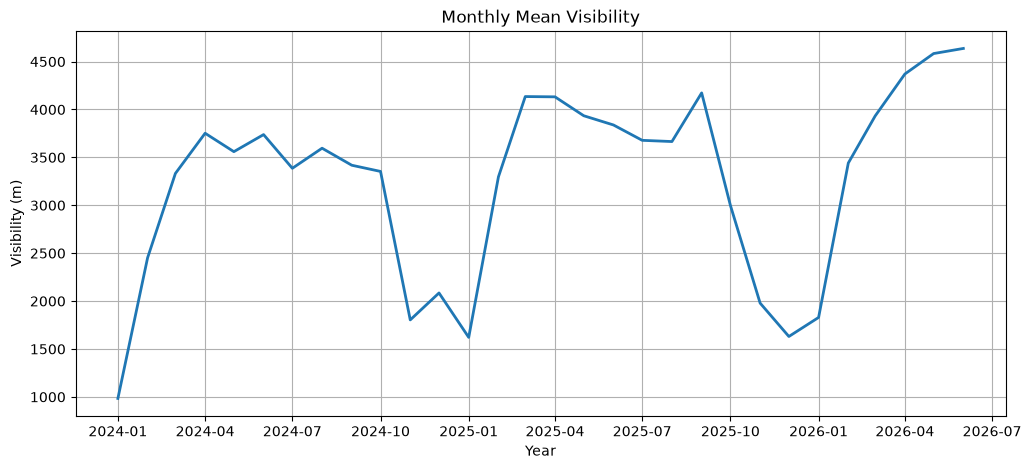

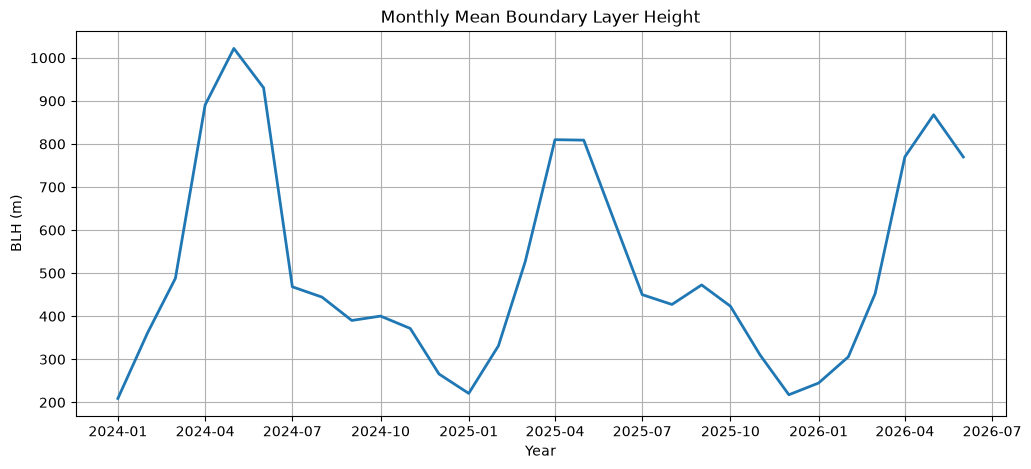

In [8]:
# PM2.5
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["PM2.5_Mean"], linewidth=2)
plt.title("Monthly Mean PM₂.₅")
plt.xlabel("Year")
plt.ylabel("PM₂.₅ (µg/m³)")
plt.grid(True)
plt.show()


# Temperature
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Temperature"], linewidth=2)
plt.title("Monthly Mean Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()


# Relative Humidity
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["RH"], linewidth=2)
plt.title("Monthly Mean Relative Humidity")
plt.xlabel("Year")
plt.ylabel("RH (%)")
plt.grid(True)
plt.show()


# Wind Speed
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["WindSpeed"], linewidth=2)
plt.title("Monthly Mean Wind Speed")
plt.xlabel("Year")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.show()


# Visibility
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["Visibility"], linewidth=2)
plt.title("Monthly Mean Visibility")
plt.xlabel("Year")
plt.ylabel("Visibility (m)")
plt.grid(True)
plt.show()


# Boundary Layer Height
plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly["BLH"], linewidth=2)
plt.title("Monthly Mean Boundary Layer Height")
plt.xlabel("Year")
plt.ylabel("BLH (m)")
plt.grid(True)
plt.show()

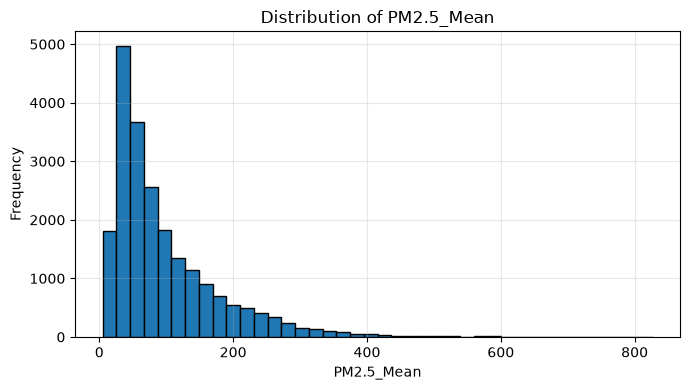

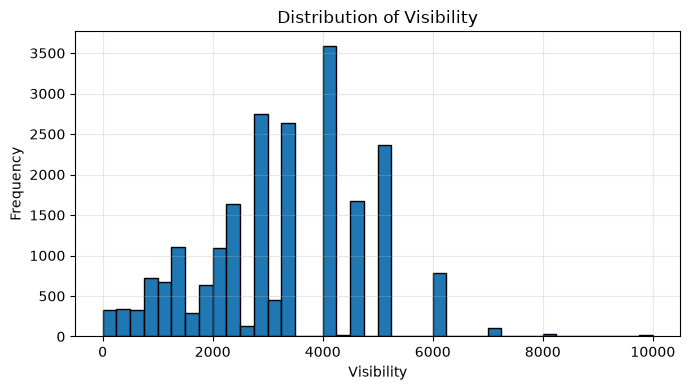

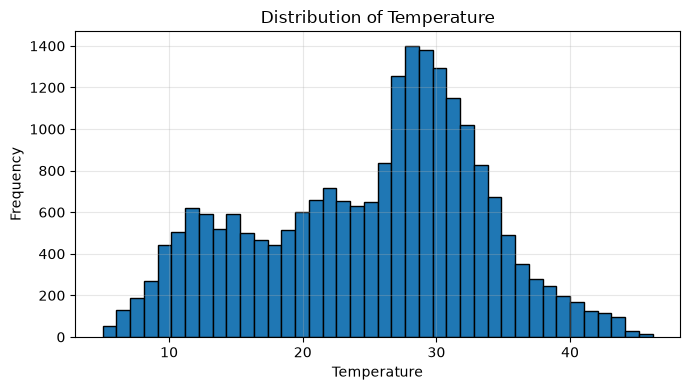

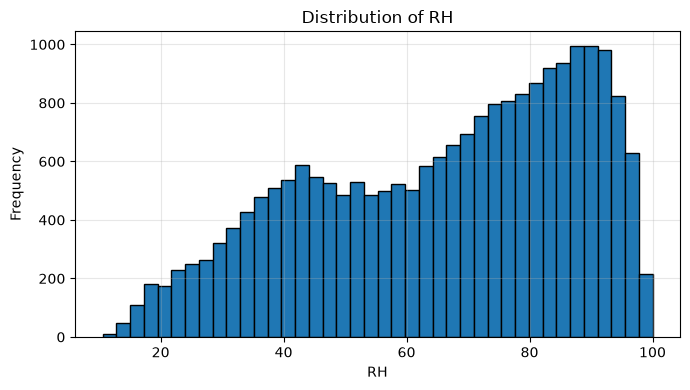

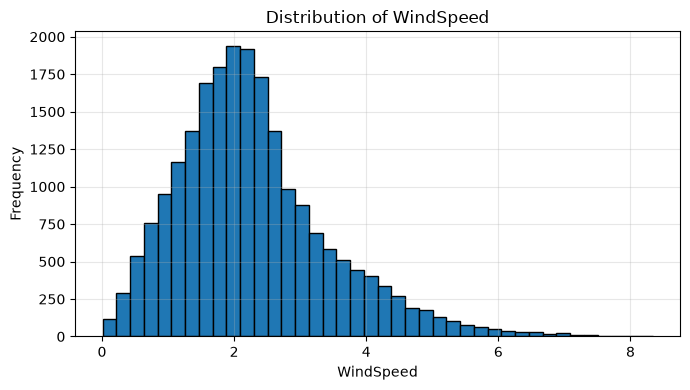

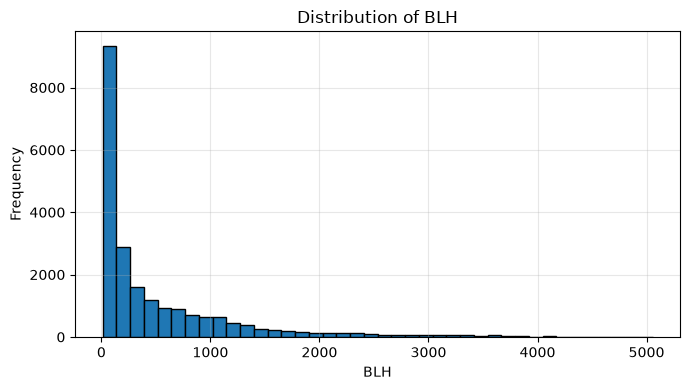

In [9]:
columns = [
    "PM2.5_Mean",
    "Visibility",
    "Temperature",
    "RH",
    "WindSpeed",
    "BLH"
]

for col in columns:

    plt.figure(figsize=(7,4))

    plt.hist(
        df[col],
        bins=40,
        edgecolor="black"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

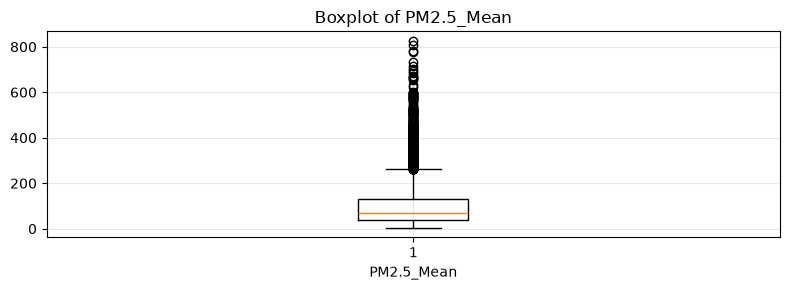

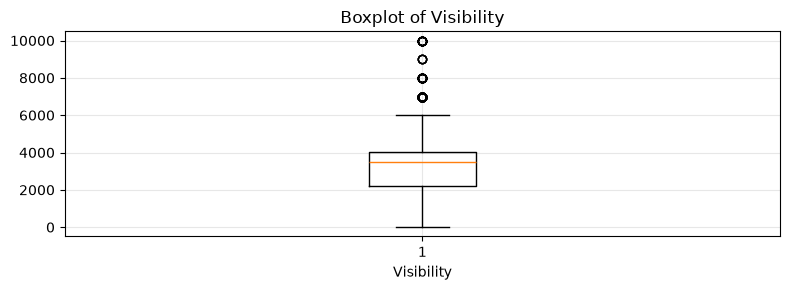

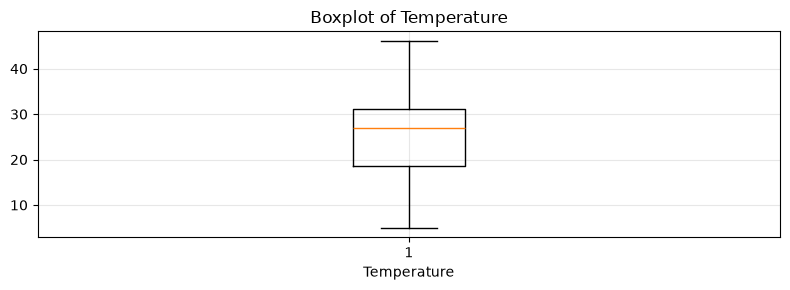

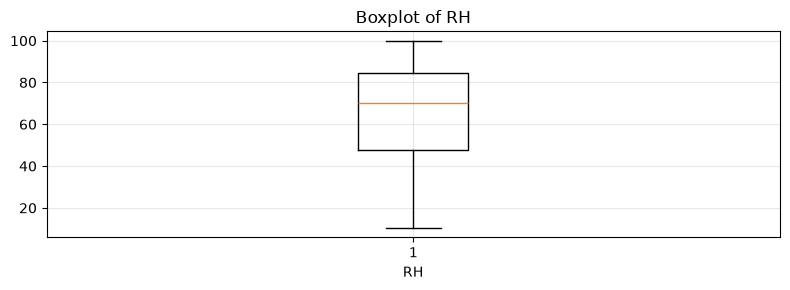

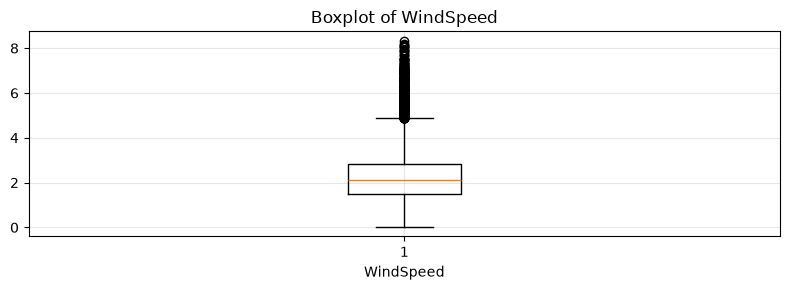

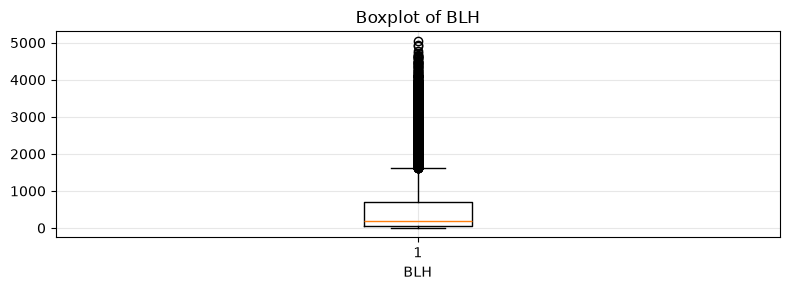

In [12]:
for col in columns:

    plt.figure(figsize=(8,3))

    plt.boxplot(df[col])

    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [14]:
corr = df[
    [
        "PM2.5_Mean",
        "Visibility",
        "Temperature",
        "RH",
        "WindSpeed",
        "BLH"
    ]
].corr(method="pearson")
print(corr.round(3))

             PM2.5_Mean  Visibility  Temperature     RH  WindSpeed    BLH
PM2.5_Mean        1.000      -0.613       -0.497  0.110     -0.177 -0.067
Visibility       -0.613       1.000        0.675 -0.546      0.272  0.434
Temperature      -0.497       0.675        1.000 -0.592      0.213  0.557
RH                0.110      -0.546       -0.592  1.000     -0.313 -0.591
WindSpeed        -0.177       0.272        0.213 -0.313      1.000  0.365
BLH              -0.067       0.434        0.557 -0.591      0.365  1.000


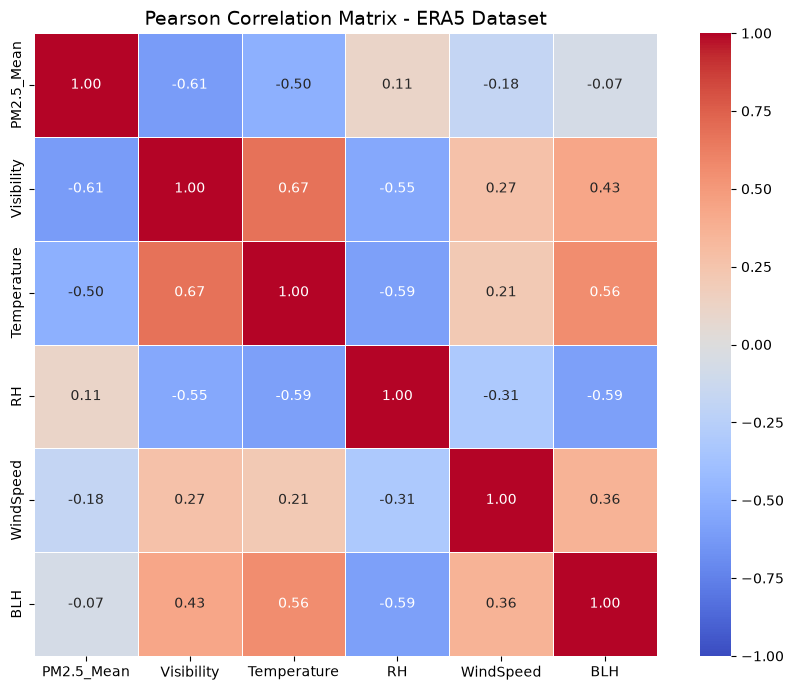

In [16]:
plt.figure(figsize=(9,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Pearson Correlation Matrix - ERA5 Dataset", fontsize=14)
plt.tight_layout()
plt.show()